# Example 02: DFT artefacts and corrections

A DFT of a sinusoid can introduce systematic errors in amplitude, frequency, and phase estimates whenever the signal does not fall on an exact DFT bin, which is the general case in practice.

Three additive correction terms are provided:

- **WINDOW** — Closed-form CFT of the windowed signal. The base analytical model: the spectrum a finite, windowed sinusoid would have in continuous time.
- **BASELINE** — The trapezoidal-rule approximation to the DFT integral gives half weight to the boundary samples; the DFT sum gives them full weight. This mismatch produces a constant offset and a frequency-dependent oscillating error whenever the windowed signal is non-zero at the boundaries, i.e. $w[0] \neq 0$ or $w[N-1] \neq 0$. Windows that taper to zero at both endpoints — Hann, Nuttall, Bartlett — have no boundary discontinuity and need no correction; rectangular and Hamming do.
- **SAMPLING** — Sampling makes the spectrum periodic with period $f_s$. The DFT therefore includes all aliased copies of the spectrum at $f \pm k\,f_s$. The SAMPLING correction adds these alias contributions up to a specified order.

With all corrections applied, the model matches the DFT to floating-point precision for sufficiently high SAMPLING order.

A short mathematical [derivation](#mathematical-background) can be found at the end of the notebook. The fitting workflow is in [Notebook 03](./03_precision_fitting.ipynb).

*Implementation: `DFTCorrection`, `DFTCorrectionMode` in [dft/correction.py](../dftmodels/dft/correction.py); `SineFourier` in [models/sinusoid.py](../dftmodels/models/sinusoid.py).*

## Model without corrections

Signal parameters: $f_0 = 10.37\,\text{Hz}$, $A = 2.0\,\text{V}$, $\varphi = 0.5\,\text{rad}$, rectangular window, $f_s = 100\,\text{Hz}$, $T = 1\,\text{s}$ ($\Delta f = 1\,\text{Hz}$), no noise.

The WINDOW-only model evaluated at the exact parameters does not match the DFT. The residual is structured and deterministic -- it originates from the missing BASELINE and SAMPLING corrections.

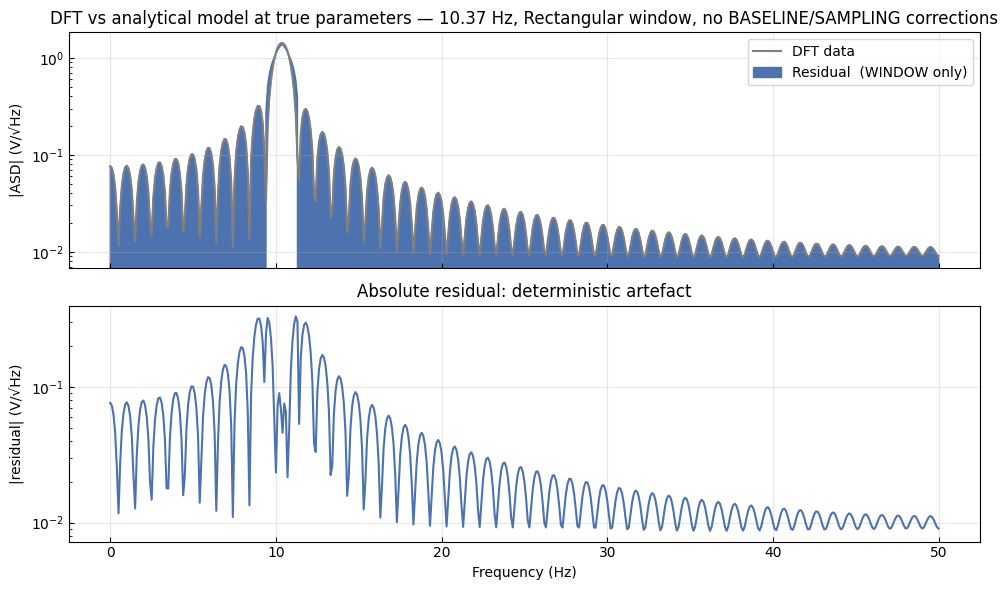

RMS residual (no corrections): 7.3064e-02 V/√Hz
Peak residual:                 3.3257e-01 V/√Hz

This is NOT noise — these are deterministic artefacts from the finite, windowed DFT.


In [1]:
# Deterministic residual without corrections at true parameters
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Path("figures").mkdir(exist_ok=True)
plt.style.use("dftmodels.mplstyle")

import lmfit

from dftmodels import (
    SignalSeries, NormType, WindowType, DFTRange, SineFourier, Sinusoid,
    DFTCorrection, DFTCorrectionMode,
)

SAMPLE_RATE     = 100.0
DURATION        = 1.0         # s  →  bin spacing Δf = 0.25 Hz
TRUE_AMPLITUDE  = 2.0         # V
TRUE_FREQUENCY  = 10.37       # Hz  (0.48 bins above the 10.25 Hz bin)
TRUE_PHASE      = 0.5         # rad
WINDOW          = WindowType.RECTANGULAR
DFT_RANGE       = DFTRange.SINGLE_SIDED

ai = TRUE_AMPLITUDE * np.cos(TRUE_PHASE)
aq = TRUE_AMPLITUDE * np.sin(TRUE_PHASE)

t = np.linspace(0, DURATION, int(SAMPLE_RATE * DURATION), endpoint=False)
y = Sinusoid.eval(t, ai, aq, TRUE_FREQUENCY)
# No noise — errors below are purely systematic, not statistical.
signal = SignalSeries(x=t, y=y)

fourier = signal.calculate_dft(
    norm=NormType.ASD, window=WINDOW, dft_range=DFT_RANGE, pad=10.0,
)

params_perfect = Sinusoid.make_params(
    amplitude_i=ai, amplitude_q=aq, frequency=TRUE_FREQUENCY
)

model_none = SineFourier(fourier.dft_config, DFTCorrection(DFTCorrectionMode.NONE))
y_none     = model_none.eval(params_perfect, fourier.x)
residual   = np.abs(fourier.y - y_none)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(fourier.x, fourier.abs.y, c="grey",  label="DFT data")
axes[0].fill_between(fourier.x, np.abs(y_none), fourier.abs.y, label="Residual  (WINDOW only)", color="C0")
axes[0].set_ylabel("|ASD| (V/√Hz)")
axes[0].set_title(
    f"DFT vs analytical model at true parameters — {TRUE_FREQUENCY} Hz, Rectangular window, no BASELINE/SAMPLING corrections"
)
axes[0].semilogy()
axes[0].legend()

axes[1].plot(fourier.x, residual, color="C0")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("|residual| (V/√Hz)")
axes[1].set_title("Absolute residual: deterministic artefact")
axes[1].semilogy()

plt.tight_layout()
plt.savefig(f"figures/02_dft_corrections_fig00.svg", bbox_inches="tight")
plt.show()

print(f"RMS residual (no corrections): {float(np.sqrt(np.mean(residual ** 2))):.4e} V/√Hz")
print(f"Peak residual:                 {float(np.max(residual)):.4e} V/√Hz")
print()
print("This is NOT noise — these are deterministic artefacts from the finite, windowed DFT.")

## Correction convergence

The model is evaluated at the exact signal parameters for each correction combination. Adding BASELINE removes the constant offset and the oscillating boundary term. Adding SAMPLING at increasing order folds in aliased copies until the residual reaches floating-point precision.

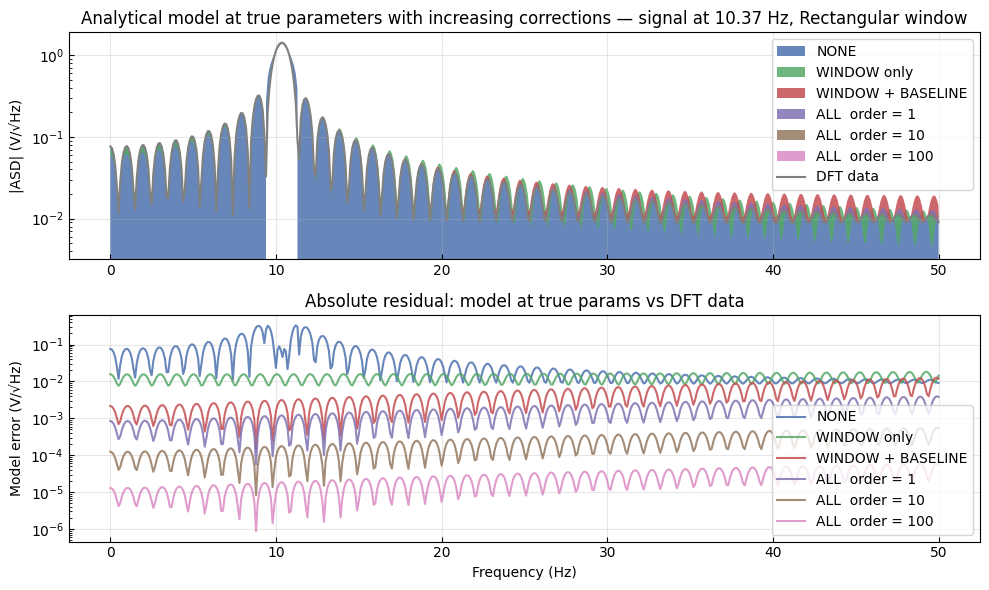

In [2]:
# Correction convergence: residual reduction at each correction level
CORRECTIONS = [
    ("NONE"             , DFTCorrection(DFTCorrectionMode.NONE)),
    ("WINDOW only"      , DFTCorrection(DFTCorrectionMode.WINDOW)),
    ("WINDOW + BASELINE", DFTCorrection(DFTCorrectionMode.BASELINE)),
    ("ALL  order = 1"   , DFTCorrection(DFTCorrectionMode.ALL,                    order=1)),
    ("ALL  order = 10"  , DFTCorrection(DFTCorrectionMode.ALL,                    order=10)),
    ("ALL  order = 100" , DFTCorrection(DFTCorrectionMode.ALL,                    order=100)),
]

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

for label, correction in CORRECTIONS:
    model  = SineFourier(fourier.dft_config, correction)
    y_model = model.eval(params_perfect, fourier.x)

    axes[0].fill_between(fourier.x, np.abs(y_model), np.abs(fourier.abs.y), alpha=0.85, label=label.strip())
    axes[1].plot(fourier.x, np.abs(fourier.y - y_model), alpha=0.85, label=label.strip())

# DFT data as reference
axes[0].plot(fourier.x, fourier.abs.y, color="grey", label="DFT data")
axes[0].set_ylabel("|ASD| (V/√Hz)")
axes[0].set_title(
    f"Analytical model at true parameters with increasing corrections — "
    f"signal at {TRUE_FREQUENCY} Hz, Rectangular window"
)
axes[0].legend()
axes[0].semilogy()

axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Model error (V/√Hz)")
axes[1].set_title("Absolute residual: model at true params vs DFT data")
axes[1].legend()
axes[1].semilogy()

plt.tight_layout()
plt.savefig(f"figures/02_dft_corrections_fig01.svg", bbox_inches="tight")
plt.show()

## Window sweep

RMS residual at true parameters for `WINDOW only` vs `ALL` (order = 100) across all supported windows. The residual floor after `ALL` corrections depends on the SAMPLING convergence rate for each window's spectral decay.

- Fast-decaying windows (Hann $\propto 1/f^3$, Nuttall $\propto 1/f^5$): aliases negligible after a few orders.
- Slow-decaying windows (rectangular $\propto 1/f$, Bartlett $\propto 1/f^2$): higher orders required for the same precision.

In [3]:
# Window sweep: RMS residual for WINDOW-only vs ALL corrections
SINE_WINDOWS = [
    WindowType.RECTANGULAR,
    WindowType.HAMMING,
    WindowType.HANN,
    WindowType.BLACKMAN,
    WindowType.NUTTAL,
    WindowType.BLACKMAN_NUTTAL,
    WindowType.FLAT_TOP,
    WindowType.BARTLETT,
]
correction_none = DFTCorrection(DFTCorrectionMode.NONE)
correction_all  = DFTCorrection(DFTCorrectionMode.ALL, order=100)

print(f"Signal at {TRUE_FREQUENCY} Hz, DURATION = {DURATION} s (Δf = {1.0/DURATION:.2f} Hz)")
print(f"{'Window':16}  {'rms (NONE)':>14}  {'rms (ALL ord=100)':>18}")
print("-" * 52)

for w in SINE_WINDOWS:
    fourier_w = signal.calculate_dft(
        norm=NormType.ASD, window=w, dft_range=DFT_RANGE, pad=10.0,
    )

    model_none = SineFourier(fourier_w.dft_config, correction_none)
    res_none = np.abs(model_none.eval(params_perfect, fourier_w.x) - fourier_w.y)

    model_all  = SineFourier(fourier_w.dft_config, correction_all)
    res_all = np.abs(model_all.eval(params_perfect, fourier_w.x) - fourier_w.y)

    print(f"{w.value:16}  {float(np.sqrt(np.mean(res_none**2))):>14.6e}  {float(np.sqrt(np.mean(res_all**2))):>18.6e}")

Signal at 10.37 Hz, DURATION = 1.0 s (Δf = 1.00 Hz)
Window                rms (NONE)   rms (ALL ord=100)
----------------------------------------------------
rectangular         7.306395e-02        2.670368e-05
hamming             1.330474e-01        3.691604e-06
hann                1.514821e-01        2.213610e-13
blackman            1.947677e-01        3.325323e-07
nuttal              2.439850e-01        1.283594e-14
blackman-nuttal     2.381072e-01        1.905077e-08
flat-top            3.703652e-01        2.699581e-08
bartlett            1.603087e-01        4.809617e-07


## SAMPLING correction: acquisition length

The alias at $f_0 \pm k\,f_s$ contributes a sinc of width $1/T$ evaluated near $f_0$. In ASD normalisation its amplitude scales as $\sim A\,/\,(k\,f_s\,\sqrt{T})$, so the SAMPLING correction becomes less important as $T = N/f_s$ grows.

The plot sweeps $N$ at fixed $f_s$ with no noise and shows the integrated RMS model error $\sqrt{\int |\hat{y} - y|^2\,df}\,/\,A$ for three correction levels — a dimensionless quantity independent of $f_s$ and $A$ via Parseval's theorem.

Horizontal lines show noise floors at fixed SNR ratios $\sigma/A$. The intersection of a model-error curve with a noise floor marks the crossover $N$: below it the fit is model-limited; above it, noise-limited. The corrections are therefore most relevant in the high-SNR, short-record regime. High SAMPLING orders (e.g. order > 10) are purely academic and included here for benchmarking only; in practice the noise floor dominates long before such precision is required.

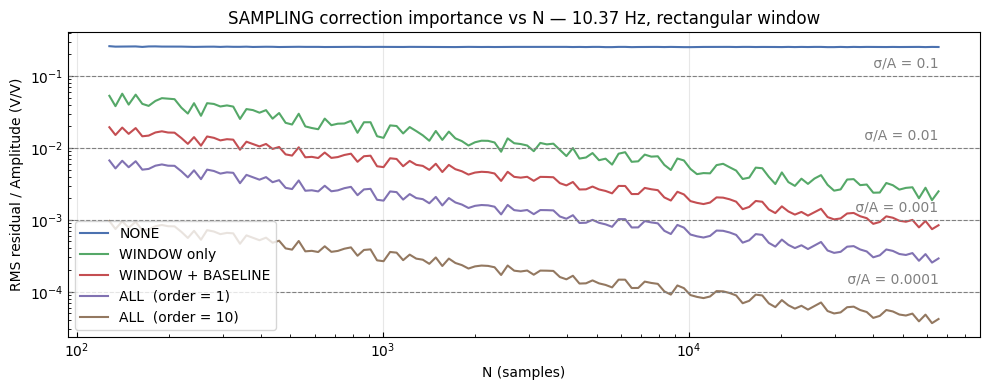

In [4]:
# SAMPLING correction importance vs acquisition length (rectangular window, no noise)
N_values = np.unique(np.round(np.geomspace(128, 65_536, 128)).astype(int))

configs = [
    ('NONE'             , DFTCorrection(DFTCorrectionMode.NONE)                               , []),
    ('WINDOW only'      , DFTCorrection(DFTCorrectionMode.WINDOW)                             , []),
    ('WINDOW + BASELINE', DFTCorrection(DFTCorrectionMode.BASELINE), []),
    ('ALL  (order = 1)' , DFTCorrection(DFTCorrectionMode.ALL, order=1)                       , []),
    ('ALL  (order = 10)', DFTCorrection(DFTCorrectionMode.ALL, order=10)                      , [])
]

p = Sinusoid.make_params(amplitude_i=ai, amplitude_q=aq, frequency=TRUE_FREQUENCY)

for N in N_values:
    t_n = np.linspace(0, N / SAMPLE_RATE, N, endpoint=False)
    f_n = SignalSeries(x=t_n, y=Sinusoid.eval(t_n, ai, aq, TRUE_FREQUENCY)).calculate_dft(
        norm=NormType.ASD, window=WindowType.RECTANGULAR, dft_range=DFT_RANGE, pad=10.0,
    )

    for _, corr, rms_list in configs:
        y_hat = SineFourier(f_n.dft_config, corr).eval(p, f_n.x)
        residual = f_n.copy()
        residual.y = f_n.y - y_hat
        rms_list.append(np.sqrt(residual.convert_to_psd().calculate_integral()) / TRUE_AMPLITUDE)

NOISE_LEVELS = [0.1, 0.01, 0.001, 0.0001]

fig, ax = plt.subplots(figsize=(10, 4))
for label, _, rms_list in configs:
    ax.loglog(N_values, rms_list, label=label)

for α in NOISE_LEVELS:
    ax.axhline(α, color='grey', linestyle='--', linewidth=0.8)
    ax.text(N_values[-1], α * 1.2, f' σ/A = {α}', va='bottom', ha="right", color='grey')

ax.set_xlabel('N (samples)')
ax.set_ylabel('RMS residual / Amplitude (V/V)')
ax.set_title(
    f'SAMPLING correction importance vs N — {TRUE_FREQUENCY} Hz, rectangular window'
)
ax.legend()
plt.tight_layout()
plt.savefig(f"figures/02_dft_corrections_fig02.svg", bbox_inches="tight")
plt.show()

## Mathematical background

The three correction terms follow from the chain **CFT → (sampling) → DTFT → (windowing) → DFT**.

### Step 1: CFT

The continuous Fourier transform (CFT) of a signal $x(t)$:

$$
X(f) = \int_{-\infty}^{\infty} x(t)\,e^{-2\pi i f t}\,dt
$$

For a sinusoid $x(t) = A\cos(2\pi f_0 t + \varphi)$, the CFT is two delta distributions at $\pm f_0$:

$$
X(f) = \tfrac{A}{2}\bigl[e^{i\varphi}\,\delta(f - f_0) + e^{-i\varphi}\,\delta(f + f_0)\bigr]
$$

For a decaying sinusoid $x(t) = A\,e^{-\gamma t}\cos(2\pi f_0 t + \varphi)\,\Theta(t)$, each delta broadens into a Lorentzian. The CFT is the spectrum of an infinite, continuously observed signal.

### Step 2: Sampling → DTFT

Sampling at rate $f_s$ ($\Delta t = 1/f_s$) produces the discrete-time Fourier transform (DTFT):

$$
X_{\text{DTFT}}(f) = \Delta t \sum_{n=-\infty}^{\infty} x(n\,\Delta t)\,e^{-2\pi i f\,n\,\Delta t}
$$

The DTFT is continuous in $f$ and periodic with period $f_s$. By the Poisson summation formula:

$$
X_{\text{DTFT}}(f) = \sum_{k=-\infty}^{\infty} X(f + k\,f_s)
$$

Each alias $k \neq 0$ is a shifted copy of the CFT. For a sinusoid, the DTFT is a comb of delta distributions; for a decaying sinusoid, a comb of Lorentzians.

The **SAMPLING correction** adds the $k \neq 0$ terms up to a specified order.

*Implementation: `FourierModelBase._sampling_correction()` in [models/base.py](../dftmodels/models/base.py).*

### Step 3: Windowing → DFT

The DFT multiplies the infinite sampled sequence by a window $w[n]$ nonzero only for $n = 0, \ldots, N{-}1$:

$$
X_{\text{DFT}}[m] = \Delta t \sum_{n=0}^{N-1} w[n]\,x(n\,\Delta t)\,e^{-2\pi i f_m\,n\,\Delta t}
$$

where $f_m = m\,\Delta f$ are the DFT bin frequencies. Windowing in time is convolution in frequency: each spectral component of the DTFT is convolved with the window's frequency response $W(f)$.

**Rectangular window** ($w[n] = 1$): convolution of a delta with the rectangular response gives a sinc. For the positive-frequency component at $f_0$:

$$
T\,|\tilde{A}|\,e^{i(\varphi + \pi(f_0 - f)T)}\,\text{sinc}\bigl((f_0 - f)\,T\bigr)
$$

where $T = (N{-}1)/f_s$ and $\tilde{A} = A\,e^{i\varphi}$. The negative-frequency component gives an analogous term at $f_0 + f$.

*Implementation: `_rect_base()` in [models/sinusoid.py](../dftmodels/models/sinusoid.py).*

**Cosine-sum windows** (Hann, Hamming, Blackman, ...): $w[n] = \sum_m a_m \cos(2\pi m\,n/(N{-}1))$. Each cosine term shifts the rectangular result by $\pm m/T$:

$$
X_{\text{win}}(f) = \sum_m \frac{a_m}{2}\Bigl[X_{\text{rect}}(f - m/T) + X_{\text{rect}}(f + m/T)\Bigr]
$$

Hann ($a_0 = 0.5,\; a_1 = -0.5$): sinc$^2$ shape. Hamming ($a_0 = 25/46,\; a_1 = -21/46$): `(4 * rect + 42 * hann) / 46`.

**Bartlett window**: $w[n] = 1 - |2n/(N{-}1) - 1|$. Spectral shape is a squared sinc of half duration.

*Implementation: `_hann_base()`, `_hamming_base()`, `_bartlett_base()` in [models/sinusoid.py](../dftmodels/models/sinusoid.py).*

The **WINDOW correction** is the closed-form result of steps 1-3 combined.

#### Boundary weight mismatch (BASELINE)

The CFT integral approximated by the trapezoidal rule on the sample grid gives half weight to the boundary samples at $n = 0$ and $n = N{-}1$: each endpoint lies at the edge of the integration domain, so only one side of the interval contributes. The DFT sum gives all samples, including the boundaries, full weight. This mismatch introduces a constant offset and a frequency-dependent oscillating error that are not captured by the WINDOW correction. The **BASELINE correction** compensates by adding the missing half-weight boundary terms:

| Term | Expression | Character |
|------|-----------|-----------|
| First sample ($n = 0$) | $+\tfrac{1}{2}\,w[0]\,s(0)$ | Constant |
| Last sample ($n = N{-}1$) | $-\tfrac{1}{2}\,w[N{-}1]\,s(T)\,e^{-2\pi i f T}$ | Oscillating with $f$ |

$$
\text{BASELINE}(f) = \tfrac{1}{2}\bigl[w[0]\,s(0) - w[N{-}1]\,s(T)\,e^{-2\pi i f T}\bigr]
$$

Windows where $w[0] = w[N{-}1] = 0$ (Hann, Nuttall, Bartlett) need no correction.

| Window | $w[0] = w[N{-}1]$ |
|--------|-------------------|
| Rectangular | 1 |
| Hamming | 4/46 |
| Blackman | 128/18608 |

*Implementation: `_rect_baseline()` in [models/sinusoid.py](../dftmodels/models/sinusoid.py).*

### Correction summary

| Correction | Origin | Content |
|------------|--------|---------|
| **WINDOW** | CFT of windowed signal | Sinc, sinc$^2$, ... shape per window |
| **SAMPLING** | Aliasing from sampling | $\sum_{k \neq 0} X(f + k\,f_s)$ |
| **BASELINE** | Boundary weight mismatch | Half-weight correction at $n = 0$ and $n = N{-}1$ |

## Summary

- Off-bin signals produce deterministic, structured residuals in the DFT that bias amplitude, frequency, and phase estimates.
- Three additive corrections address three distinct origins: the windowed CFT shape (WINDOW), aliasing from sampling (SAMPLING), and boundary weight mismatch (BASELINE).
- Required SAMPLING order for floating-point precision depends on the window’s spectral decay rate. Smoothly-decaying windows (Hann, Nuttall) converge in a few orders; rectangular and Bartlett require higher orders.
- The SAMPLING correction becomes negligible above a crossover acquisition length that scales with the window’s spectral decay rate; see the N-sweep plot above. At typical noise levels the noise floor often dominates before that crossover.
- All corrections apply to every supported window function.